In [ ]:
# =========================
# 1. Imports y carga de datos
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    balanced_accuracy_score,
    f1_score
)
from sklearn.ensemble import RandomForestClassifier

df = pd.read_csv("../data/dataset.csv")

df.columns = df.columns.str.replace("\ufeff", "", regex=False)

print("Dimensiones del dataset:", df.shape)
display(df.head())

Dimensiones del dataset: (4424, 35)


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,8,5,2,1,1,1,13,10,6,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,6,1,11,1,1,1,1,3,4,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,5,1,1,1,22,27,10,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,8,2,15,1,1,1,23,27,6,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,12,1,3,0,1,1,22,28,10,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [26]:
# =========================
# 2. Separación train/test
# =========================

X = df.drop(columns=["Target"])
y = df["Target"]

class_names = sorted(y.unique())

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)
print()
print("Distribución de clases en train:")
display(y_train.value_counts(normalize=True).round(4))
print("Distribución de clases en test:")
display(y_test.value_counts(normalize=True).round(4))

X_train: (3539, 34)
X_test: (885, 34)
y_train: (3539,)
y_test: (885,)

Distribución de clases en train:


Target
Graduate    0.4993
Dropout     0.3213
Enrolled    0.1794
Name: proportion, dtype: float64

Distribución de clases en test:


Target
Graduate    0.4994
Dropout     0.3209
Enrolled    0.1797
Name: proportion, dtype: float64

In [27]:
# =========================
# 3. Random Forest con todas las variables
# =========================

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [28]:
# =========================
# 4. Métricas Random Forest con todas las variables
# =========================

rf_metrics_df = pd.DataFrame({
    "Modelo": ["Random Forest - Todas las variables"] * 4,
    "Métrica": [
        "Accuracy",
        "Balanced accuracy",
        "Macro F1",
        "Weighted F1"
    ],
    "Valor": [
        accuracy_score(y_test, y_pred_rf),
        balanced_accuracy_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_rf, average="macro"),
        f1_score(y_test, y_pred_rf, average="weighted")
    ]
})

rf_metrics_df["Valor"] = rf_metrics_df["Valor"].round(4)

display(rf_metrics_df)

,Modelo,Métrica,Valor
0,Random Forest - Todas las variables,Accuracy,0.7593
1,Random Forest - Todas las variables,Balanced accuracy,0.6872
2,Random Forest - Todas las variables,Macro F1,0.6939
3,Random Forest - Todas las variables,Weighted F1,0.7547


In [29]:
# =========================
# 5. Classification report Random Forest
# =========================

rf_report_df = pd.DataFrame(
    classification_report(
        y_test,
        y_pred_rf,
        output_dict=True
    )
).T.round(4)

display(rf_report_df)

,precision,recall,f1-score,support
Dropout,0.8240,0.7254,0.7715,284.0000
Enrolled,0.4828,0.4403,0.4605,159.0000
Graduate,0.8082,0.8959,0.8498,442.0000
accuracy,0.7593,0.7593,0.7593,0.7593
macro avg,0.7050,0.6872,0.6939,885.0000
weighted avg,0.7548,0.7593,0.7547,885.0000


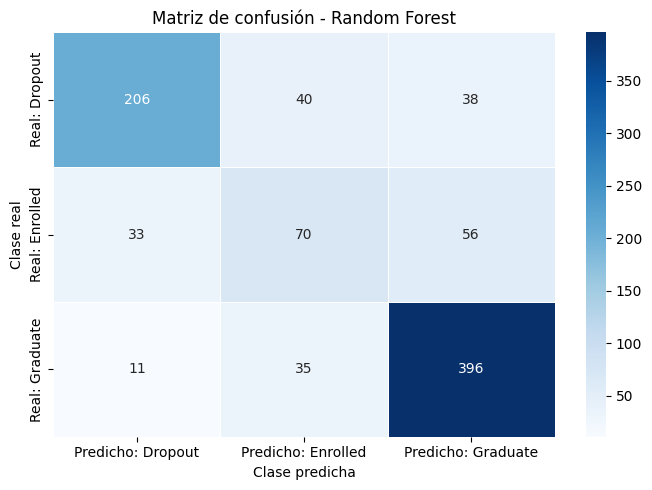

In [30]:
# =========================
# 7. Matriz de confusión Random Forest como gráfico
# =========================

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_rf_df,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=0.5,
    cbar=True
)

plt.title("Matriz de confusión - Random Forest")
plt.xlabel("Clase predicha")
plt.ylabel("Clase real")
plt.tight_layout()
plt.show()

In [31]:
# =========================
# 8. Variables iniciales disponibles en matrícula
# =========================

initial_features = [
    "Marital status",
    "Application mode",
    "Application order",
    "Course",
    "Daytime/evening attendance",
    "Previous qualification",
    "Nacionality",
    "Mother's qualification",
    "Father's qualification",
    "Mother's occupation",
    "Father's occupation",
    "Displaced",
    "Educational special needs",
    "Debtor",
    "Tuition fees up to date",
    "Gender",
    "Scholarship holder",
    "Age at enrollment",
    "International",
    "Unemployment rate",
    "Inflation rate",
    "GDP"
]

X_initial = df[initial_features]
y = df["Target"]

print("Número de variables usadas en el escenario inicial:", X_initial.shape[1])
display(X_initial.head())

Número de variables usadas en el escenario inicial: 22


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Unemployment rate,Inflation rate,GDP
0,1,8,5,2,1,1,1,13,10,6,...,0,0,1,1,0,20,0,10.8,1.4,1.74
1,1,6,1,11,1,1,1,1,3,4,...,0,0,0,1,0,19,0,13.9,-0.3,0.79
2,1,1,5,5,1,1,1,22,27,10,...,0,0,0,1,0,19,0,10.8,1.4,1.74
3,1,8,2,15,1,1,1,23,27,6,...,0,0,1,0,0,20,0,9.4,-0.8,-3.12
4,2,12,1,3,0,1,1,22,28,10,...,0,0,1,0,0,45,0,13.9,-0.3,0.79


In [32]:
# =========================
# 9. Separación train/test con variables iniciales
# =========================

X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(
    X_initial,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("X_train_i:", X_train_i.shape)
print("X_test_i:", X_test_i.shape)
print("y_train_i:", y_train_i.shape)
print("y_test_i:", y_test_i.shape)

X_train_i: (3539, 22)
X_test_i: (885, 22)
y_train_i: (3539,)
y_test_i: (885,)


In [33]:
# =========================
# 10. Random Forest con variables iniciales
# =========================

rf_initial = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_initial.fit(X_train_i, y_train_i)
y_pred_i = rf_initial.predict(X_test_i)

In [34]:
# =========================
# 11. Métricas Random Forest con variables iniciales
# =========================

initial_metrics_df = pd.DataFrame({
    "Modelo": ["Random Forest - Variables iniciales"] * 4,
    "Métrica": [
        "Accuracy",
        "Balanced accuracy",
        "Macro F1",
        "Weighted F1"
    ],
    "Valor": [
        accuracy_score(y_test_i, y_pred_i),
        balanced_accuracy_score(y_test_i, y_pred_i),
        f1_score(y_test_i, y_pred_i, average="macro"),
        f1_score(y_test_i, y_pred_i, average="weighted")
    ]
})

initial_metrics_df["Valor"] = initial_metrics_df["Valor"].round(4)

display(initial_metrics_df)

,Modelo,Métrica,Valor
0,Random Forest - Variables iniciales,Accuracy,0.6124
1,Random Forest - Variables iniciales,Balanced accuracy,0.5344
2,Random Forest - Variables iniciales,Macro F1,0.5358
3,Random Forest - Variables iniciales,Weighted F1,0.6026


In [35]:
# =========================
# 12. Classification report con variables iniciales
# =========================

initial_report_df = pd.DataFrame(
    classification_report(
        y_test_i,
        y_pred_i,
        output_dict=True
    )
).T.round(4)

display(initial_report_df)

,precision,recall,f1-score,support
Dropout,0.6380,0.6268,0.6323,284.0000
Enrolled,0.3193,0.2390,0.2734,159.0000
Graduate,0.6694,0.7376,0.7018,442.0000
accuracy,0.6124,0.6124,0.6124,0.6124
macro avg,0.5422,0.5344,0.5358,885.0000
weighted avg,0.5964,0.6124,0.6026,885.0000


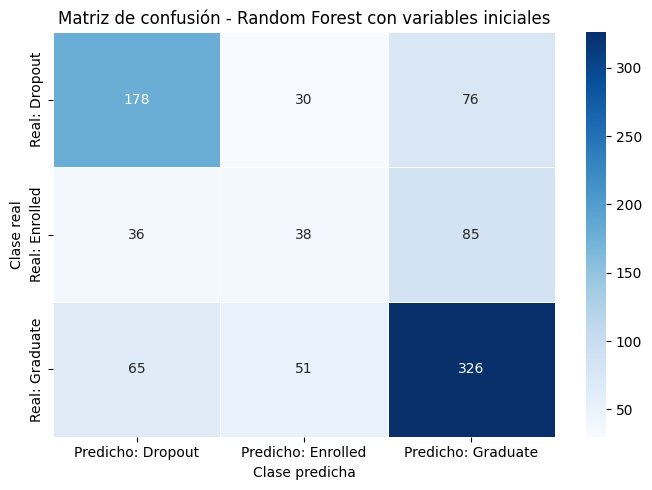

In [36]:
# =========================
# 14. Matriz de confusión con variables iniciales como gráfico
# =========================

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_initial_df,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=0.5,
    cbar=True
)

plt.title("Matriz de confusión - Random Forest con variables iniciales")
plt.xlabel("Clase predicha")
plt.ylabel("Clase real")
plt.tight_layout()
plt.show()

In [37]:
# =========================
# 15. Comparativa de modelos
# =========================

baseline_results = pd.DataFrame({
    "Modelo": ["Regresión logística - Todas las variables"] * 4,
    "Métrica": [
        "Accuracy",
        "Balanced accuracy",
        "Macro F1",
        "Weighted F1"
    ],
    "Valor": [
        0.7390,
        0.7124,
        0.7008,
        0.7518
    ]
})

comparison_df = pd.concat(
    [
        baseline_results,
        rf_metrics_df,
        initial_metrics_df
    ],
    ignore_index=True
)

comparison_pivot = comparison_df.pivot(
    index="Modelo",
    columns="Métrica",
    values="Valor"
)

comparison_pivot = comparison_pivot[
    ["Accuracy", "Balanced accuracy", "Macro F1", "Weighted F1"]
]

display(comparison_pivot.round(4))

Métrica,Accuracy,Balanced accuracy,Macro F1,Weighted F1
Modelo,,,,
Random Forest - Todas las variables,0.7593,0.6872,0.6939,0.7547
Random Forest - Variables iniciales,0.6124,0.5344,0.5358,0.6026
Regresión logística - Todas las variables,0.7390,0.7124,0.7008,0.7518


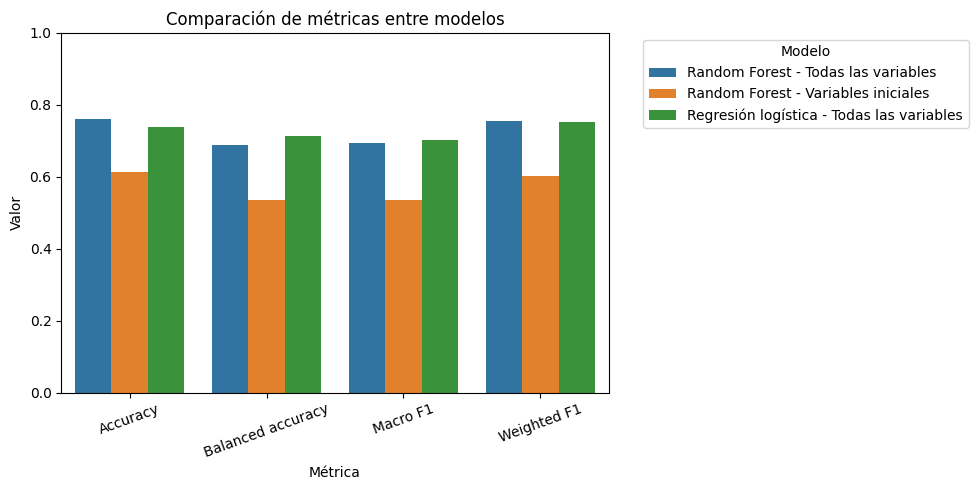

In [38]:
# =========================
# 16. Gráfico comparativo de modelos
# =========================

comparison_plot_df = comparison_pivot.reset_index().melt(
    id_vars="Modelo",
    var_name="Métrica",
    value_name="Valor"
)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=comparison_plot_df,
    x="Métrica",
    y="Valor",
    hue="Modelo"
)

plt.title("Comparación de métricas entre modelos")
plt.ylabel("Valor")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.legend(title="Modelo", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()